In [4]:
# ── Cell 0: Imports ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight

import shap
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

print('All imports successful')

All imports successful


In [ ]:
# Config
# All variable names, filtering thresholds, and structural parameters
# are defined here rather than hardcoded throughout the notebook.
# When replacing synthetic data with real SAIL / Birmingham data,
# only this cell needs to be updated.

CONFIG = {
    # Outcome variable
    'outcome':          'DIED',

    # Patient ID — used for group-level splitting
    'patient_id':       'SEQN',

    # Features for model training
    'features':         ['AGE', 'SEX', 'BMI', 'SBP', 'HBA1C_MMOL', 'LOG_UACR'],

    # Categorical features — reported as counts/% not mean
    'categorical':      ['SEX', 'ETHNICITY'],

    # Continuous features — reported as mean +/- SD
    'continuous':       ['AGE', 'BMI', 'SBP', 'HBA1C_MMOL', 'LOG_UACR', 'FOLLOW_UP_YEARS'],

    # Clinical range filters
    # Note: missingness rates below are illustrative placeholders
    # and will be updated when real dataset characteristics are available
    'filters': {
        'HBA1C_MMOL': (20, 195),
        'BMI':        (14, 70),
        'SBP':        (60, 280),
        'AGE_MIN':    18
    },

    # Missingness rates for synthetic data
    # These are placeholders — real rates will vary by dataset and variable
    'missingness': {
        'HBA1C': 0.05,
        'BMI':   0.03,
        'SBP':   0.04
    },

    # Split proportions: 88% development / 12% test, then 80/20 dev -> train/tune
    'test_size':        0.12,
    'tune_size':        0.20,

    # Sample size
    'n_patients':       50000,

    # Outcome prevalence for synthetic data
    'outcome_prev':     0.15,

    # Random seed
    'seed':             42,
}

print('Config loaded')
print(f"N = {CONFIG['n_patients']:,} | Outcome prevalence = {CONFIG['outcome_prev']*100:.0f}%")

Config loaded
N = 50,000 | Outcome prevalence = 15%


In [ ]:
# Synthetic data generation

np.random.seed(CONFIG['seed'])
n = CONFIG['n_patients']
seqn = np.arange(100000, 100000 + n)

# Demographics
demo = pd.DataFrame({
    'SEQN':      seqn,
    'AGE':       np.random.normal(58, 14, n).clip(18, 85).astype(int),
    'SEX':       np.random.choice([1, 2], n),
    'ETHNICITY': np.random.choice([1, 2, 3, 4, 6, 7], n,
                                   p=[0.50, 0.10, 0.20, 0.10, 0.05, 0.05])
})

# Clinical variables with conditional dependence
# Higher HbA1c patients tend to have higher SBP and UACR
hba1c_base = np.random.normal(7.2, 1.8, n).clip(4.5, 14.0)
sbp_base   = 125 + 3.5 * hba1c_base + np.random.normal(0, 15, n)
uacr_base  = np.exp(0.18 * hba1c_base + np.random.normal(0.8, 1.0, n)).clip(0.1, 1000)

biol = pd.DataFrame({'SEQN': seqn, 'HBA1C': hba1c_base})
bp   = pd.DataFrame({'SEQN': seqn, 'SBP':   sbp_base.clip(90, 200)})
bmx  = pd.DataFrame({'SEQN': seqn, 'BMI':   np.random.normal(29, 6, n).clip(15, 60)})
alb  = pd.DataFrame({'SEQN': seqn, 'UACR':  uacr_base})

# Outcome: higher HbA1c and UACR increase risk
log_odds = (
    -3.5
    + 0.03  * demo['AGE']
    + 0.18  * hba1c_base
    + 0.25  * np.log1p(uacr_base)
    + 0.008 * sbp_base
    + np.random.normal(0, 0.5, n)
)
prob_event = 1 / (1 + np.exp(-log_odds))

mort = pd.DataFrame({
    'SEQN':             seqn,
    'DIED':             np.random.binomial(1, prob_event),
    'FOLLOW_UP_MONTHS': np.random.exponential(120, n).clip(1, 240).astype(int)
})

diab = pd.DataFrame({
    'SEQN':   seqn,
    'DIQ010': np.random.choice([1, 2, 3, 9], n, p=[0.15, 0.75, 0.05, 0.05])
})

# Introduce realistic missingness
for df_name, col, pct in [
    (biol, 'HBA1C', CONFIG['missingness']['HBA1C']),
    (bmx,  'BMI',   CONFIG['missingness']['BMI']),
    (bp,   'SBP',   CONFIG['missingness']['SBP'])
]:
    df_name.loc[df_name.sample(frac=pct, random_state=CONFIG['seed']).index, col] = np.nan

print(f'Synthetic dataset: {n:,} patients')
print(f'Overall mortality rate: {mort["DIED"].mean()*100:.1f}%')

Synthetic dataset: 50,000 patients
Overall mortality rate: 75.8%


In [ ]:
#Merge, feature engineering, filtering
df = (
    demo
    .merge(biol, on='SEQN')
    .merge(bp,   on='SEQN')
    .merge(bmx,  on='SEQN')
    .merge(alb,  on='SEQN')
    .merge(mort, on='SEQN')
    .merge(diab, on='SEQN')
)

# Keep T2D patients only
df = df[df['DIQ010'] == 1].copy()

# Feature engineering
df['HBA1C_MMOL']      = (df['HBA1C'] - 2.15) * 10.929
df['LOG_UACR']        = np.log1p(df['UACR'])
df['FOLLOW_UP_YEARS'] = df['FOLLOW_UP_MONTHS'] / 12
df['AGE_GROUP']       = pd.cut(df['AGE'],
                                bins=[17, 40, 55, 70, 100],
                                labels=['<40', '40-55', '55-70', '70+'])

# Clinical range filters
f = CONFIG['filters']
df = df[
    (df['HBA1C_MMOL'].between(*f['HBA1C_MMOL'])) &
    (df['BMI'].between(*f['BMI'])) &
    (df['SBP'].between(*f['SBP'])) &
    (df['AGE'] >= f['AGE_MIN'])
]

print(f'Sample after filtering: {len(df):,} patients')
print(f'Outcome rate: {df[CONFIG["outcome"]].mean()*100:.1f}%')
print(f'\nMissing values:')
print(df[CONFIG['features']].isnull().sum())

Sample after filtering: 7,169 patients
Outcome rate: 75.9%

Missing values:
AGE           0
SEX           0
BMI           0
SBP           0
HBA1C_MMOL    0
LOG_UACR      0
dtype: int64


In [8]:
#Descriptive statistics ────────────────────────────────────────
print('=== CONTINUOUS VARIABLES (mean ± SD) ===')
print(df[CONFIG['continuous']].describe().round(2))

# Categorical variables: counts and percentages NOT mean
print('\n=== CATEGORICAL VARIABLES (count, %) ===')
for col in CONFIG['categorical']:
    print(f'\n{col}:')
    counts = df[col].value_counts()
    pcts   = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': counts, 'Percent': pcts.round(1)})
    print(summary)

print('\n=== CLASS BALANCE ===')
outcome_counts = df[CONFIG['outcome']].value_counts()
outcome_pcts   = df[CONFIG['outcome']].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': outcome_counts, 'Percent': outcome_pcts.round(1)}))

# Correlation matrix
print('\n=== CORRELATION MATRIX ===')
print(df[CONFIG['features'] + [CONFIG['outcome']]].corr().round(3))

=== CONTINUOUS VARIABLES (mean ± SD) ===
           AGE      BMI      SBP  HBA1C_MMOL  LOG_UACR  FOLLOW_UP_YEARS
count  7169.00  7169.00  7169.00     7169.00   7169.00          7169.00
mean     57.14    29.02   149.97       56.03      2.27             8.55
std      13.85     5.98    16.12       18.74      0.90             6.62
min      18.00    15.00    91.17       25.68      0.14             0.08
25%      48.00    24.85   138.95       42.22      1.62             2.83
50%      57.00    29.02   149.87       55.20      2.20             6.83
75%      67.00    33.11   160.92       68.77      2.86            13.67
max      85.00    49.74   200.00      129.51      5.97            20.00

=== CATEGORICAL VARIABLES (count, %) ===

SEX:
     Count  Percent
SEX                
1     3589     50.1
2     3580     49.9

ETHNICITY:
           Count  Percent
ETHNICITY                
1           3581     50.0
3           1444     20.1
4            736     10.3
2            728     10.2
7            35

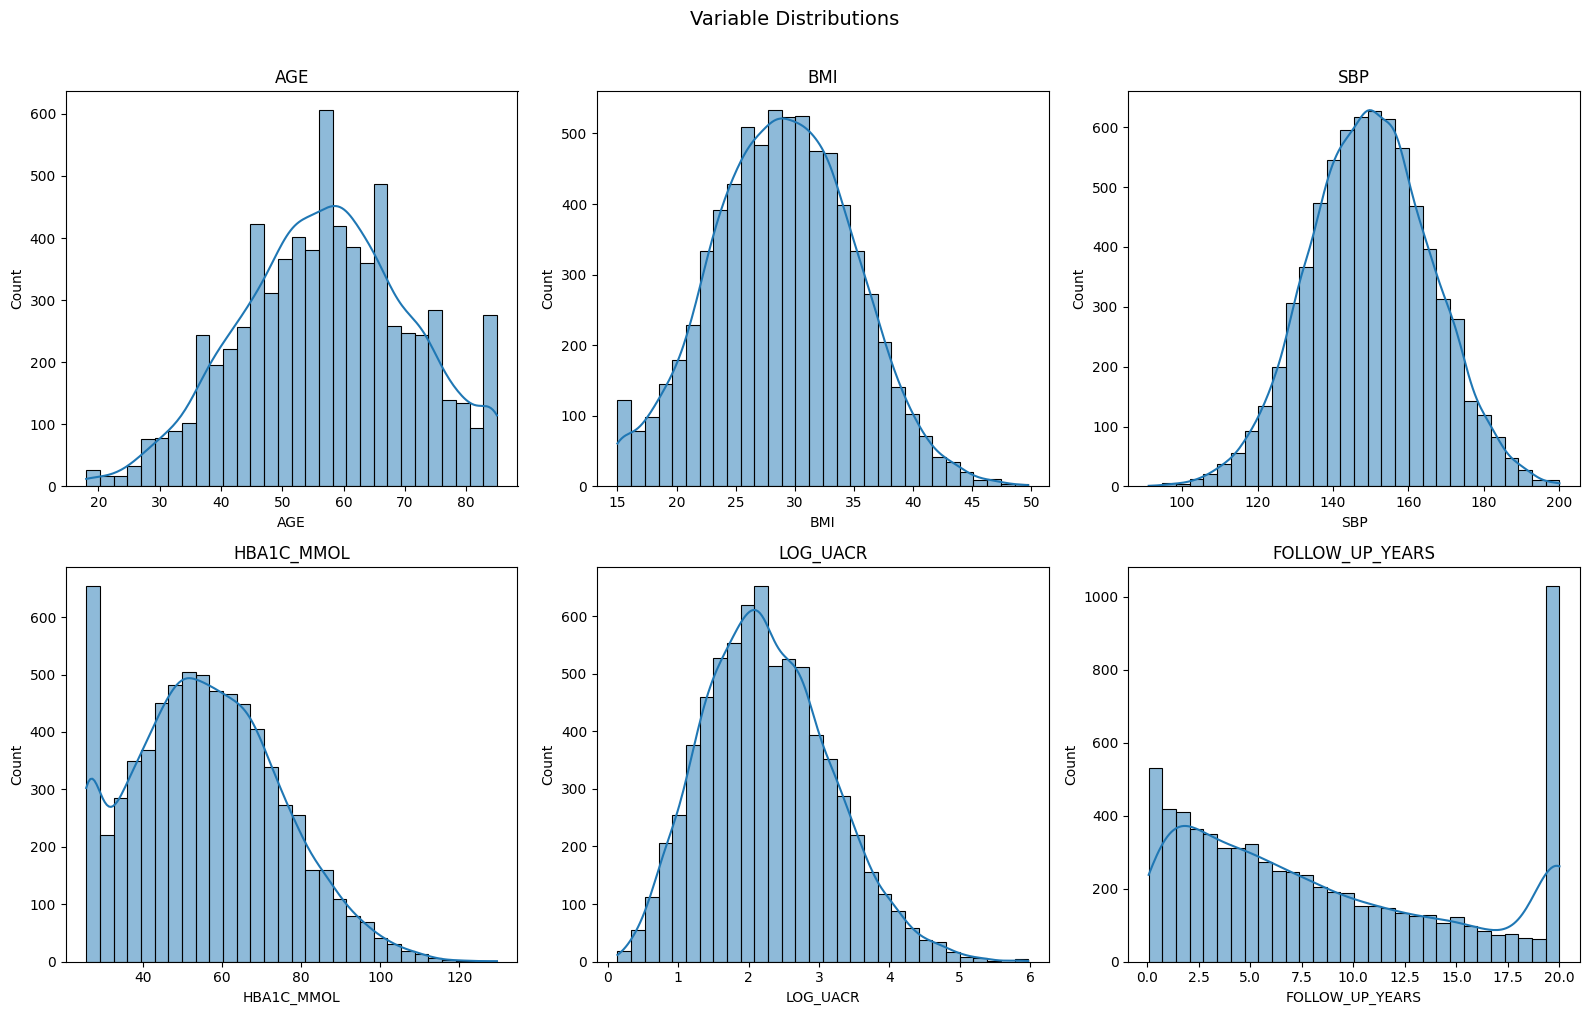

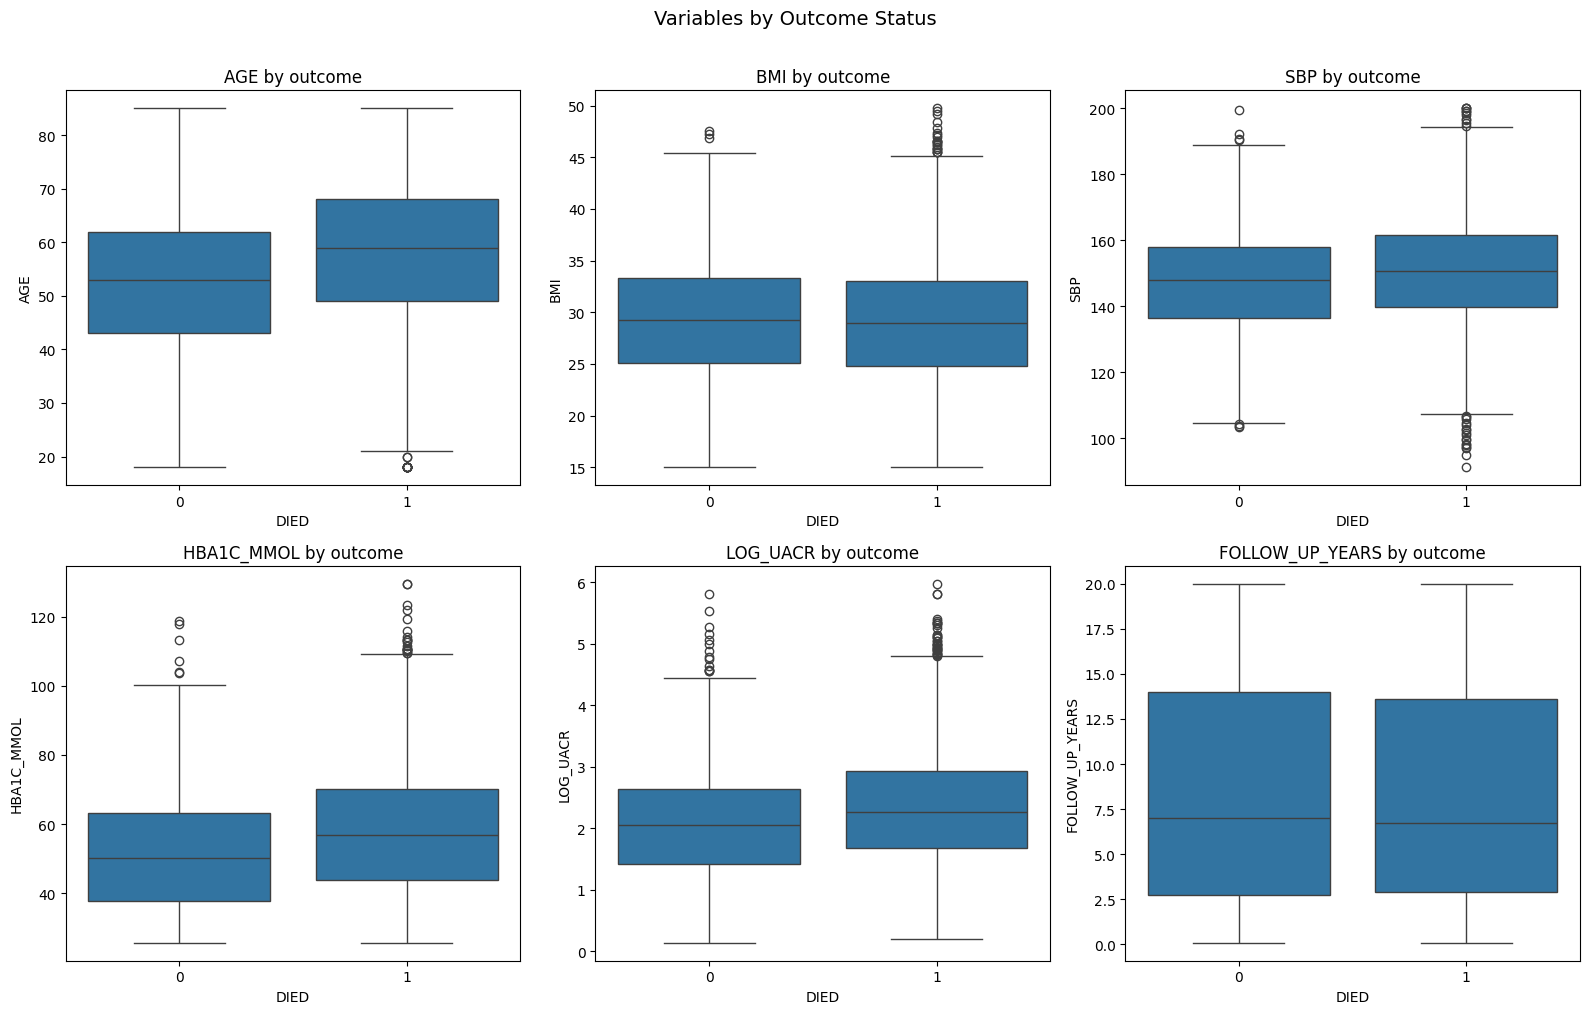

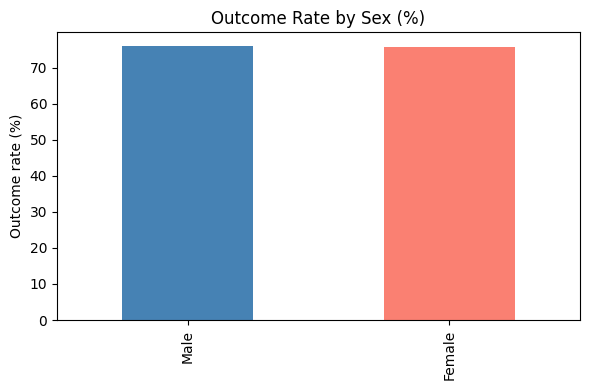

In [9]:
#EDA visualisation ─────────────────────────────────────────────
vars_to_plot = ['AGE', 'BMI', 'SBP', 'HBA1C_MMOL', 'LOG_UACR', 'FOLLOW_UP_YEARS']

# Distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, var in zip(axes.flatten(), vars_to_plot):
    sns.histplot(df[var].dropna(), ax=ax, kde=True, bins=30)
    ax.set_title(var)
plt.suptitle('Variable Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# By outcome
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, var in zip(axes.flatten(), vars_to_plot):
    sns.boxplot(x=CONFIG['outcome'], y=var, data=df, ax=ax)
    ax.set_title(f'{var} by outcome')
plt.suptitle('Variables by Outcome Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# SEX as bar chart (categorical — not boxplot)
fig, ax = plt.subplots(figsize=(6, 4))
sex_outcome = df.groupby('SEX')[CONFIG['outcome']].mean() * 100
sex_outcome.index = ['Male' if x == 1 else 'Female' for x in sex_outcome.index]
sex_outcome.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])
ax.set_title('Outcome Rate by Sex (%)')
ax.set_ylabel('Outcome rate (%)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [10]:
# Data splitting
#
# Split strategy:
#   Step 1: GroupShuffleSplit by SEQN (patient ID) — development 88% / test 12%
#           This ensures all records for a patient stay together in one set.
#           Critical for real eye-level data where one patient has multiple rows.
#   Step 2: GroupShuffleSplit again on development set — train 80% / tune 20%
#   Final: ~70% train / ~10% tune / ~20% test
#
# Both splits stratify by outcome to maintain class balance across all sets.

features  = CONFIG['features']
outcome   = CONFIG['outcome']
patient_id = CONFIG['patient_id']

X = df[features].copy()
y = df[outcome].values
groups = df[patient_id].values

# Step 1: Development / Test
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=CONFIG['test_size'],
    random_state=CONFIG['seed']
)
dev_idx, test_idx = next(gss.split(X, y, groups))

X_dev,  X_test  = X.iloc[dev_idx],  X.iloc[test_idx]
y_dev,  y_test  = y[dev_idx],       y[test_idx]
grp_dev         = groups[dev_idx]

# Step 2: Train / Tune
gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=CONFIG['tune_size'],
    random_state=CONFIG['seed']
)
train_idx, tune_idx = next(gss2.split(X_dev, y_dev, grp_dev))

X_train, X_tune = X_dev.iloc[train_idx], X_dev.iloc[tune_idx]
y_train, y_tune = y_dev[train_idx],      y_dev[tune_idx]

total = len(df)
print(f'Train : {len(X_train):,} rows ({len(X_train)/total*100:.1f}%)')
print(f'Tune  : {len(X_tune):,}  rows ({len(X_tune)/total*100:.1f}%)')
print(f'Test  : {len(X_test):,}  rows ({len(X_test)/total*100:.1f}%)')
print(f'\nOutcome rate — Train: {y_train.mean()*100:.1f}%  Tune: {y_tune.mean()*100:.1f}%  Test: {y_test.mean()*100:.1f}%')
print(f'\nPositive cases — Train: {y_train.sum()}  Tune: {y_tune.sum()}  Test: {y_test.sum()}')

Train : 5,046 rows (70.4%)
Tune  : 1,262  rows (17.6%)
Test  : 861  rows (12.0%)

Outcome rate — Train: 75.7%  Tune: 76.5%  Test: 75.6%

Positive cases — Train: 3822  Tune: 966  Test: 651


In [11]:
# Imputation and scaling ────────────────────────────────────────
# Imputer and scaler fitted on TRAIN only, then applied to tune and test.
# Fitting on the full dataset before splitting causes data leakage.

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_tune  = imputer.transform(X_tune)
X_test  = imputer.transform(X_test)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_tune  = scaler.transform(X_tune)
X_test  = scaler.transform(X_test)

print('Imputation and scaling complete (fit on train only)')

Imputation and scaling complete (fit on train only)


In [12]:
# Class weighting 
# Class weighting addresses the imbalance 
# by assigning higher weight to the minority class in the loss function.
# This forces the model to penalise misclassification of positive cases
# more heavily than misclassification of negative cases.
#
# Note: accuracy is a poor metric for class imbalance — a model predicting
# 'no event' for all patients achieves 85% accuracy with zero clinical utility.
# AUC-ROC and AUPRC are the appropriate metrics.

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = {0: weights[0], 1: weights[1]}
print(f'Class weights: {class_weight_dict}')
print(f'Weight ratio (positive:negative) = {weights[1]/weights[0]:.2f}')

Class weights: {0: np.float64(2.0612745098039214), 1: np.float64(0.6601255886970173)}
Weight ratio (positive:negative) = 0.32


In [13]:
# TabNet hyperparameter tuning  
# Tune set used for early stopping and model selection.
# Test set is never seen during training or selection.

param_grid = [
    {'n_d': 8,  'n_a': 8,  'n_steps': 3, 'gamma': 1.3, 'lr': 0.02, 'batch_size': 512},
    {'n_d': 16, 'n_a': 16, 'n_steps': 4, 'gamma': 1.5, 'lr': 0.01, 'batch_size': 512},
    {'n_d': 32, 'n_a': 32, 'n_steps': 5, 'gamma': 1.3, 'lr': 0.01, 'batch_size': 1024},
    {'n_d': 16, 'n_a': 16, 'n_steps': 3, 'gamma': 1.5, 'lr': 0.02, 'batch_size': 256},
]

best_auc    = 0
best_params = None
best_clf    = None

print('--- Hyperparameter tuning on tune set ---')
for params in param_grid:
    clf = TabNetClassifier(
        n_d=params['n_d'],
        n_a=params['n_a'],
        n_steps=params['n_steps'],
        gamma=params['gamma'],
        optimizer_params=dict(lr=params['lr']),
        seed=CONFIG['seed'],
        verbose=0
    )
    clf.fit(
        X_train, y_train,
        eval_set=[(X_tune, y_tune)],
        eval_name=['tune'],
        eval_metric=['auc'],
        max_epochs=100,
        patience=15,
        batch_size=params['batch_size'],
        virtual_batch_size=params['batch_size'] // 4,
        weights=1,          # Apply class weighting in loss function
    )
    tune_auc = roc_auc_score(y_tune, clf.predict_proba(X_tune)[:, 1])
    print(f"  n_d={params['n_d']:2d}, n_steps={params['n_steps']}, lr={params['lr']} "
          f"→ Tune AUC: {tune_auc:.4f}")

    if tune_auc > best_auc:
        best_auc    = tune_auc
        best_params = params
        best_clf    = clf

print(f'\nBest tune AUC : {best_auc:.4f}')
print(f'Best params   : {best_params}')

--- Hyperparameter tuning on tune set ---

Early stopping occurred at epoch 35 with best_epoch = 20 and best_tune_auc = 0.6563
  n_d= 8, n_steps=3, lr=0.02 → Tune AUC: 0.6563


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 21 with best_epoch = 6 and best_tune_auc = 0.64165


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  n_d=16, n_steps=4, lr=0.01 → Tune AUC: 0.6417

Early stopping occurred at epoch 27 with best_epoch = 12 and best_tune_auc = 0.66416


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  n_d=32, n_steps=5, lr=0.01 → Tune AUC: 0.6642

Early stopping occurred at epoch 40 with best_epoch = 25 and best_tune_auc = 0.67701


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  n_d=16, n_steps=3, lr=0.02 → Tune AUC: 0.6770

Best tune AUC : 0.6770
Best params   : {'n_d': 16, 'n_a': 16, 'n_steps': 3, 'gamma': 1.5, 'lr': 0.02, 'batch_size': 256}


=== TabNet Test Set Performance ===
AUC-ROC  : 0.6772
AUPRC    : 0.8604
F1       : 0.6500

Positive cases in test set: 651 / 861

Classification report:
              precision    recall  f1-score   support

           0       0.33      0.75      0.46       210
           1       0.86      0.52      0.65       651

    accuracy                           0.58       861
   macro avg       0.60      0.63      0.56       861
weighted avg       0.74      0.58      0.60       861

Confusion matrix:
[[157  53]
 [312 339]]


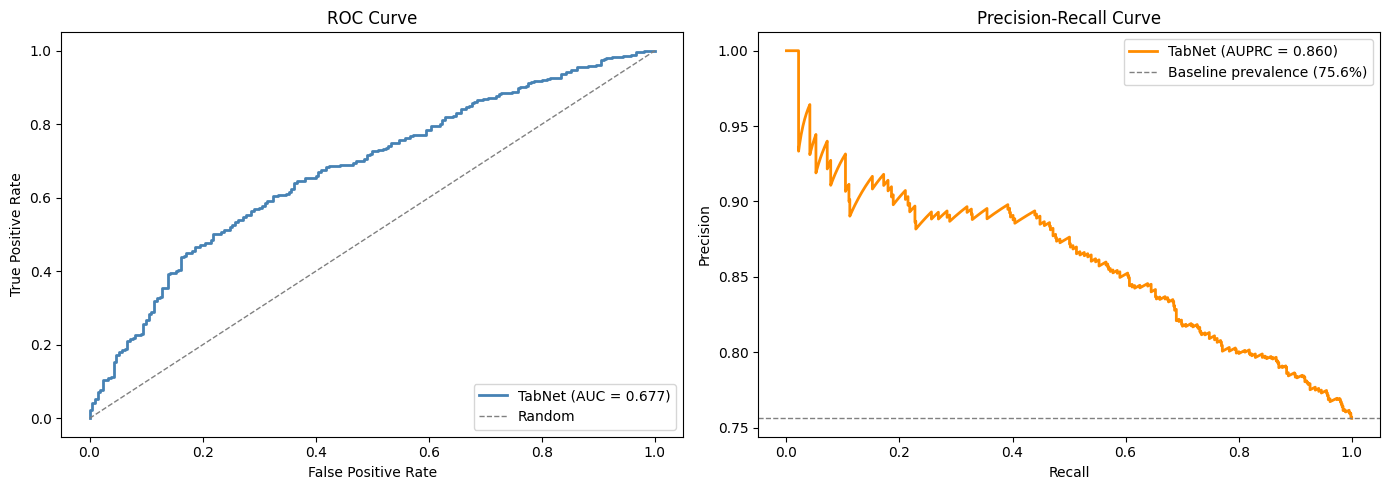

In [ ]:
# Evaluation on held-out test set 
# Test set used ONCE only — to evaluate the final chosen model.

y_pred_proba = best_clf.predict_proba(X_test)[:, 1]
y_pred       = best_clf.predict(X_test)

auc_roc = roc_auc_score(y_test, y_pred_proba)
auprc   = average_precision_score(y_test, y_pred_proba)

print('=== TabNet Test Set Performance ===')
print(f'AUC-ROC  : {auc_roc:.4f}')
print(f'AUPRC    : {auprc:.4f}')
print(f'F1       : {f1_score(y_test, y_pred):.4f}')
print(f'\nPositive cases in test set: {y_test.sum()} / {len(y_test)}')
print('\nClassification report:')
print(classification_report(y_test, y_pred))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))

# AUROC curve 
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'TabNet (AUC = {auc_roc:.3f})')
axes[0].plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(rec, prec, color='darkorange', lw=2, label=f'TabNet (AUPRC = {auprc:.3f})')
axes[1].axhline(y_test.mean(), color='grey', linestyle='--', lw=1,
                label=f'Baseline prevalence ({y_test.mean()*100:.1f}%)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

=== TabNet Feature Importances ===
   Feature  Importance
       AGE    0.332665
HBA1C_MMOL    0.309846
       SBP    0.145685
       SEX    0.076732
       BMI    0.073117
  LOG_UACR    0.061955


/tmp/ipykernel_15538/1112147707.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_d')


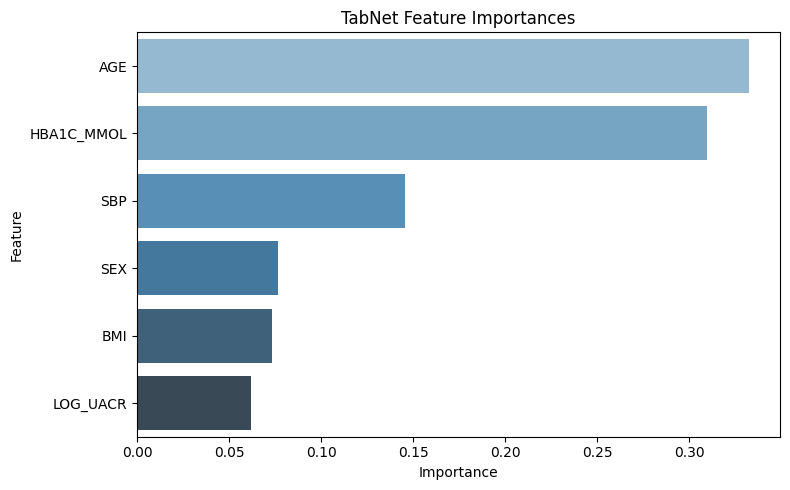

In [15]:
# Cell 11: Feature importances 
importance_df = pd.DataFrame({
    'Feature':    features,
    'Importance': best_clf.feature_importances_
}).sort_values('Importance', ascending=False)

print('=== TabNet Feature Importances ===')
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_d')
plt.title('TabNet Feature Importances')
plt.tight_layout()
plt.show()

ExactExplainer explainer: 501it [02:53,  2.79it/s]                         
/tmp/ipykernel_15538/3920186632.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


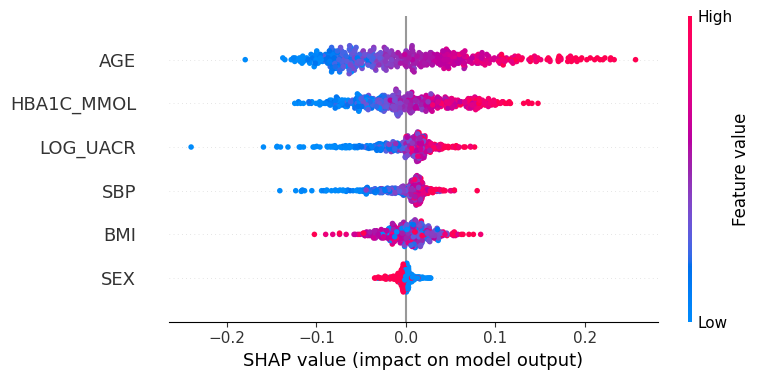

/tmp/ipykernel_15538/3920186632.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


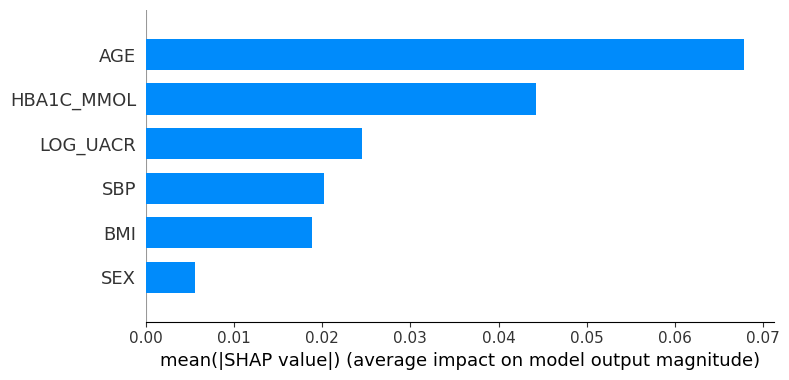

In [16]:
# SHAP explainability 
# SHAP (SHapley Additive exPlanations) explains individual model predictions
# by quantifying the contribution of each feature to each prediction.
# This moves beyond global feature importance to patient-level explanations.

# Use a subsample for efficiency
np.random.seed(CONFIG['seed'])
shap_idx     = np.random.choice(len(X_test), size=min(500, len(X_test)), replace=False)
X_test_shap  = X_test[shap_idx]

explainer    = shap.Explainer(
    lambda x: best_clf.predict_proba(x)[:, 1],
    X_test_shap
)
shap_values  = explainer(X_test_shap)

# Summary plot — shows feature impact across all patients
plt.figure()
shap.summary_plot(
    shap_values.values,
    X_test_shap,
    feature_names=features,
    show=True
)

# Bar plot — mean absolute SHAP values
plt.figure()
shap.summary_plot(
    shap_values.values,
    X_test_shap,
    feature_names=features,
    plot_type='bar',
    show=True
)

In [17]:
# Pipeline summary 
print('=== Pipeline Summary ===')
print(f'Sample size         : {len(df):,} T2D patients')
print(f'Outcome prevalence  : {df[outcome].mean()*100:.1f}%')
print(f'Train / Tune / Test : {len(X_train):,} / {len(X_tune):,} / {len(X_test):,}')
print(f'Positive cases test : {y_test.sum()}')
print(f'Best params         : {best_params}')
print(f'AUC-ROC (test)      : {auc_roc:.4f}')
print(f'AUPRC (test)        : {auprc:.4f}')
print(f'\nNext steps:')
print('  1. Replace synthetic data with real SAIL / Birmingham data')
print('  2. Implement GroupShuffleSplit with real patient IDs')
print('  3. Add threshold optimisation for clinical deployment')
print('  4. Explore resampling techniques (SMOTE, undersampling)')
print('  5. Add image pipeline using open-access DR dataset (e.g. Kaggle)')

=== Pipeline Summary ===
Sample size         : 7,169 T2D patients
Outcome prevalence  : 75.9%
Train / Tune / Test : 5,046 / 1,262 / 861
Positive cases test : 651
Best params         : {'n_d': 16, 'n_a': 16, 'n_steps': 3, 'gamma': 1.5, 'lr': 0.02, 'batch_size': 256}
AUC-ROC (test)      : 0.6772
AUPRC (test)        : 0.8604

Next steps:
  1. Replace synthetic data with real SAIL / Birmingham data
  2. Implement GroupShuffleSplit with real patient IDs
  3. Add threshold optimisation for clinical deployment
  4. Explore resampling techniques (SMOTE, undersampling)
  5. Add image pipeline using open-access DR dataset (e.g. Kaggle)
